
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

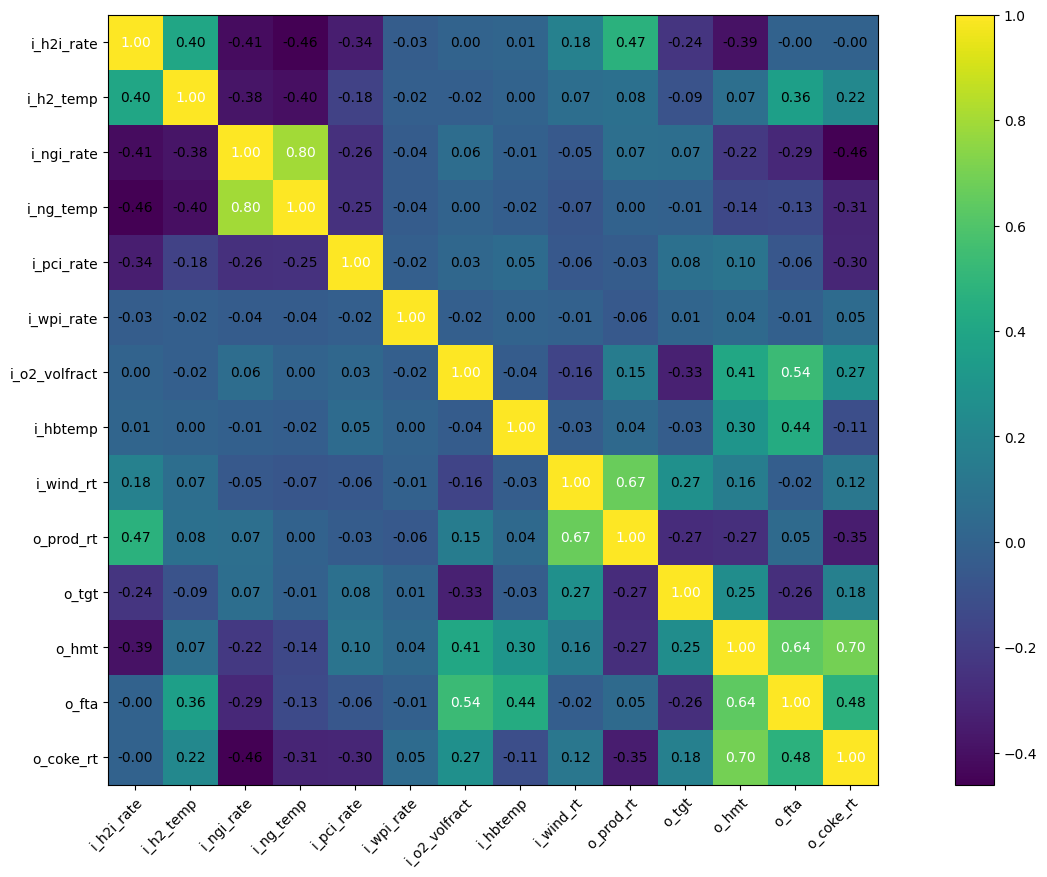

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.6950322985649109
100 ..... 0.17187072336673737
200 ..... 0.2783218324184418
300 ..... 0.24817372858524323
400 ..... 0.2621459364891052
500 ..... 0.3379642367362976
600 ..... 0.29543808102607727
700 ..... 0.1507890373468399
800 ..... 0.3136257529258728
900 ..... 0.5903993248939514


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.9485, 1304.1671, 8425.0605, 2309.4424,  417.6610]])
y_deviations: tensor([[  50.4507,  525.8995, 1512.5171,  212.9402,   50.1688]])
x_means: tensor([[  12.4106,   18.7042,   41.1898,   25.6104,  418.2296, 1439.8400,
          198.4309]])
x_deviations: tensor([[ 15.2433,  45.5605,  46.6024,   3.3430, 274.5688, 157.6511,  26.5443]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.4978,  778.2676, 6912.5435, 2096.5022,  367.4922]])
tensor([[ 148.3992, 1830.0667, 9937.5781, 2522.3826,  467.8298]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8327,  -26.8563,   -5.4126,   22.2674,  143.6608, 1282.1888,
          171.8865]])
tensor([[  27.6540,   64.2647,   87.7922,   28.9534,  692.7983, 1597.4911,
          224.9752]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.01        ## 0.1    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 400 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
    
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 726.5547485351562...H2, PCI, NGI: [[139.13785 116.84699 106.31279]]
real cost       : 80.0
total loss tensor([34.0904], grad_fn=<AddBackward0>)
loss_main tensor(26.8236, grad_fn=<MeanBackward0>)
loss_cost tensor([7.2655], grad_fn=<MulBackward0>)
iteration 400 cost: 175.22232055664062...H2, PCI, NGI: [[34.168797 21.018621 35.057037]]
real cost       : 80.0
total loss tensor([2.2749], grad_fn=<AddBackward0>)
loss_main tensor(0.4941, grad_fn=<MeanBackward0>)
loss_cost tensor([1.7522], grad_fn=<MulBackward0>)
iteration 800 cost: 98.61527252197266...H2, PCI, NGI: [[18.22702  13.212599 24.989176]]
real cost       : 80.0
total loss tensor([1.0784], grad_fn=<AddBackward0>)
loss_main tensor(0.0532, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9862], grad_fn=<MulBackward0>)
iteration 1200 cost: 70.25261688232422...H2, PCI, NGI: [[12.367759 10.174278 21.214603]]
real cost       : 80.0
total loss tensor([0.7908], grad_fn=<AddBackward0>)
loss_main tensor(0.0390, grad_fn=<MeanBackw

iteration 1600 cost: 99.38955688476562...H2, PCI, NGI: [[  8.346579   8.597241 114.81201 ]]
real cost       : 160.0
total loss tensor([1.1839], grad_fn=<AddBackward0>)
loss_main tensor(0.1277, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9939], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.1873875    7.2490435  123.961624    29.359413   333.82532
  1303.0634     218.94922  ]]
real
[  30.    0.   80.   27.  300. 1600.  230.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[   83.1390,  1134.8739, 10462.4307,  2262.5068,   382.4649]])
y real
tensor([[   84.3410,  1030.7234, 11374.7812,  2294.3977,   365.6049]])
5
********************************
iteration 0 cost: 738.5756225585938...H2, PCI, NGI: [[142.33176  115.58212  107.332855]]
real cost       : 160.0
total loss tensor([32.6448], grad_fn=<AddBackward0>)
loss_main tensor(25.2578, grad_fn=<MeanBackward0>)
loss_cost tensor([7.385

iteration 400 cost: 160.392822265625...H2, PCI, NGI: [[30.988987 16.418697 40.036354]]
real cost       : 20.5
total loss tensor([2.5865], grad_fn=<AddBackward0>)
loss_main tensor(0.9562, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6039], grad_fn=<MulBackward0>)
iteration 800 cost: 82.84449768066406...H2, PCI, NGI: [[15.025489  7.553551 30.377983]]
real cost       : 20.5
total loss tensor([1.1133], grad_fn=<AddBackward0>)
loss_main tensor(0.2421, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8284], grad_fn=<MulBackward0>)
iteration 1200 cost: 56.843265533447266...H2, PCI, NGI: [[ 9.560642  5.625903 25.949587]]
real cost       : 20.5
total loss tensor([0.7321], grad_fn=<AddBackward0>)
loss_main tensor(0.1064, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5684], grad_fn=<MulBackward0>)
iteration 1600 cost: 44.176780700683594...H2, PCI, NGI: [[ 6.858944  4.965301 23.551405]]
real cost       : 20.5
total loss tensor([0.6137], grad_fn=<AddBackward0>)
loss_main tensor(0.1019, grad_fn=<MeanBack

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.2818832    6.1470532   92.38382     21.511988   511.48206
  1483.4652     215.38672  ]]
real
[   0.  175.    0.   24.  300. 1480.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[ 134.7083, 1073.8927, 8565.2305, 2160.4832,  379.7216]])
y real
tensor([[ 113.6045, 1207.6104, 8531.3271, 2157.3381,  339.7475]])
14
********************************
iteration 0 cost: 664.51171875...H2, PCI, NGI: [[116.38551  148.04112  101.856995]]
real cost       : 45.0
total loss tensor([20.9824], grad_fn=<AddBackward0>)
loss_main tensor(14.3359, grad_fn=<MeanBackward0>)
loss_cost tensor([6.6451], grad_fn=<MulBackward0>)
iteration 400 cost: 166.97056579589844...H2, PCI, NGI: [[27.625765 36.13625  40.662502]]
real cost       : 45.0
total loss tensor([1.8324], grad_fn=<AddBackward0>)
loss_main tensor(0.1428, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6697], grad_fn=<MulBac

iteration 800 cost: 90.34163665771484...H2, PCI, NGI: [[14.080309 16.204237 35.63232 ]]
real cost       : 80.0
total loss tensor([1.1405], grad_fn=<AddBackward0>)
loss_main tensor(0.1907, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9034], grad_fn=<MulBackward0>)
iteration 1200 cost: 69.17171478271484...H2, PCI, NGI: [[ 9.359817 12.635394 38.194103]]
real cost       : 80.0
total loss tensor([0.9940], grad_fn=<AddBackward0>)
loss_main tensor(0.2426, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6917], grad_fn=<MulBackward0>)
iteration 1600 cost: 61.35895538330078...H2, PCI, NGI: [[ 6.871686  11.0877695 45.568886 ]]
real cost       : 80.0
total loss tensor([0.9314], grad_fn=<AddBackward0>)
loss_main tensor(0.2510, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6136], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   5.2320104   10.729933    50.96452     26.862091   408.5721
  1474.7916     219.14935  ]]

...

iteration 800 cost: 84.95597076416016...H2, PCI, NGI: [[14.566955 14.891381 23.59354 ]]
real cost       : 45.0
total loss tensor([0.9371], grad_fn=<AddBackward0>)
loss_main tensor(0.0533, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8496], grad_fn=<MulBackward0>)
iteration 1200 cost: 58.6909294128418...H2, PCI, NGI: [[ 9.622777  10.3390255 19.721594 ]]
real cost       : 45.0
total loss tensor([0.6506], grad_fn=<AddBackward0>)
loss_main tensor(0.0214, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5869], grad_fn=<MulBackward0>)
iteration 1600 cost: 44.13225555419922...H2, PCI, NGI: [[ 6.9499345  7.957842  16.749355 ]]
real cost       : 45.0
total loss tensor([0.5194], grad_fn=<AddBackward0>)
loss_main tensor(0.0266, grad_fn=<MeanBackward0>)
loss_cost tensor([0.4413], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   5.3744183    6.335187    15.4208555   27.248537   458.11682
  1474.8458     175.86943 

iteration 400 cost: 169.55479431152344...H2, PCI, NGI: [[30.883911 21.899612 48.239075]]
real cost       : 80.0
total loss tensor([1.9813], grad_fn=<AddBackward0>)
loss_main tensor(0.2582, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6955], grad_fn=<MulBackward0>)
iteration 800 cost: 112.83099365234375...H2, PCI, NGI: [[18.74999  14.399718 46.86263 ]]
real cost       : 80.0
total loss tensor([1.2970], grad_fn=<AddBackward0>)
loss_main tensor(0.1326, grad_fn=<MeanBackward0>)
loss_cost tensor([1.1283], grad_fn=<MulBackward0>)
iteration 1200 cost: 93.50541687011719...H2, PCI, NGI: [[13.605821 11.948009 54.26824 ]]
real cost       : 80.0
total loss tensor([1.1064], grad_fn=<AddBackward0>)
loss_main tensor(0.1272, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9351], grad_fn=<MulBackward0>)
iteration 1600 cost: 79.68529510498047...H2, PCI, NGI: [[10.179587 12.260747 53.412395]]
real cost       : 80.0
total loss tensor([1.0130], grad_fn=<AddBackward0>)
loss_main tensor(0.1648, grad_fn=<MeanBac

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   5.4135656    6.810522    20.750309    27.09643    440.36453
  1460.0479     213.16093  ]]
real
[   0.    0.   41.   24.  300. 1600.  230.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  97.0160, 1911.3533, 8462.1768, 2521.5820,  474.0423]])
y real
tensor([[ 139.2115, 2022.3313, 8403.2559, 2485.3015,  465.7507]])
988
********************************
iteration 0 cost: 574.53662109375...H2, PCI, NGI: [[ 97.717354 136.84456   93.645256]]
real cost       : 41.0
total loss tensor([24.0073], grad_fn=<AddBackward0>)
loss_main tensor(18.2594, grad_fn=<MeanBackward0>)
loss_cost tensor([5.7454], grad_fn=<MulBackward0>)
iteration 400 cost: 117.87937927246094...H2, PCI, NGI: [[18.730839 32.885815 20.140404]]
real cost       : 41.0
total loss tensor([1.6418], grad_fn=<AddBackward0>)
loss_main tensor(0.4296, grad_fn=<MeanBackward0>)
loss_cost tensor([1.1788], grad_fn=<Mu

iteration 800 cost: 98.53839111328125...H2, PCI, NGI: [[ 8.604371 19.89055  88.46071 ]]
real cost       : 200.0
total loss tensor([1.1870], grad_fn=<AddBackward0>)
loss_main tensor(0.1652, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9854], grad_fn=<MulBackward0>)
iteration 1200 cost: 88.75596618652344...H2, PCI, NGI: [[ 5.8500104 16.812277  97.0873   ]]
real cost       : 200.0
total loss tensor([1.0953], grad_fn=<AddBackward0>)
loss_main tensor(0.1637, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8876], grad_fn=<MulBackward0>)
iteration 1600 cost: 86.31289672851562...H2, PCI, NGI: [[  4.875086  15.980128 101.664856]]
real cost       : 200.0
total loss tensor([1.0753], grad_fn=<AddBackward0>)
loss_main tensor(0.1634, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8631], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   4.258773   15.853512  104.585      25.026693  459.3493   1401.6489
   216.84908 ]]

iteration 400 cost: 150.9288787841797...H2, PCI, NGI: [[25.014908 24.840311 52.057873]]
real cost       : 160.0
total loss tensor([1.7829], grad_fn=<AddBackward0>)
loss_main tensor(0.2471, grad_fn=<MeanBackward0>)
loss_cost tensor([1.5093], grad_fn=<MulBackward0>)
iteration 800 cost: 101.55379486083984...H2, PCI, NGI: [[15.324668 15.677608 49.155025]]
real cost       : 160.0
total loss tensor([1.2879], grad_fn=<AddBackward0>)
loss_main tensor(0.2288, grad_fn=<MeanBackward0>)
loss_cost tensor([1.0155], grad_fn=<MulBackward0>)
iteration 1200 cost: 86.75224304199219...H2, PCI, NGI: [[10.982418 11.832591 61.979954]]
real cost       : 160.0
total loss tensor([1.1325], grad_fn=<AddBackward0>)
loss_main tensor(0.2123, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8675], grad_fn=<MulBackward0>)
iteration 1600 cost: 82.44989013671875...H2, PCI, NGI: [[ 8.366869 10.216962 77.530914]]
real cost       : 160.0
total loss tensor([1.0598], grad_fn=<AddBackward0>)
loss_main tensor(0.1780, grad_fn=<Mean

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 304.9318


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 633.173


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -32.7200487478598
average percent diff: 97.8910695199322 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 78.27827827827828 % of cases


In [40]:

print(total)
print(better)


999
782


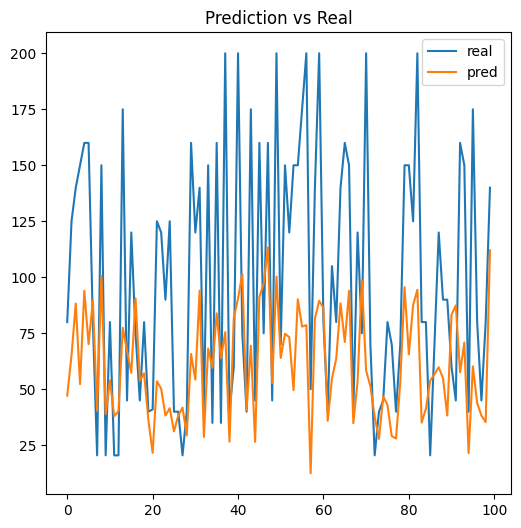

In [41]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


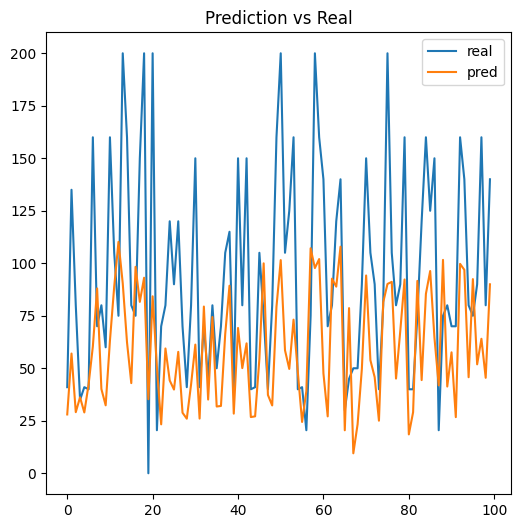

In [42]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


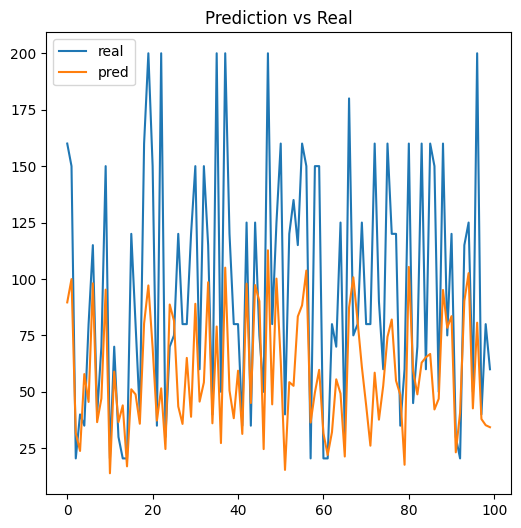

In [43]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()
